# **Gapminder introduction to data science using R**
By [Carlos Mendez](https://carlos-mendez.org)

## The Gapminder story

Hans Rosling's famous visualization reveals:

* **Global poverty:** In 1810, nearly all countries were poor and sick.
* **Big divergence:** The Industrial Revolution propelled Western nations forward, creating a vast gap with colonized regions.
* **Some convergence:** Post-colonialism, some developing countries significantly improved their health and wealth, narrowing the historical divide.

> Explore and discover our world in data: https://ourworldindata.org

## Data science workflow

![](https://r4ds.hadley.nz/diagrams/data-science/base.png)

Source: [R for Data Science](https://r4ds.hadley.nz/)

## Setup

In [2]:
library(tidyverse)
library(broom)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Import data

In [3]:
url <- "https://github.com/quarcs-lab/data-open/raw/master/isds/gapminder.csv"
df <- read_csv(url)
df

Rows: 1704 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): country, continent
dbl (4): year, lifeExp, pop, gdpPercap

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


country,continent,year,lifeExp,pop,gdpPercap
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,Asia,1952,28.801,8425333,779.4453
Afghanistan,Asia,1957,30.332,9240934,820.8530
Afghanistan,Asia,1962,31.997,10267083,853.1007
Afghanistan,Asia,1967,34.020,11537966,836.1971
Afghanistan,Asia,1972,36.088,13079460,739.9811
Afghanistan,Asia,1977,38.438,14880372,786.1134
Afghanistan,Asia,1982,39.854,12881816,978.0114
Afghanistan,Asia,1987,40.822,13867957,852.3959
Afghanistan,Asia,1992,41.674,16317921,649.3414


In [4]:
# Check dimensions
dim(df)

[1] 1704    6

In [5]:
# First rows
head(df, 5)

country,continent,year,lifeExp,pop,gdpPercap
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,Asia,1952,28.801,8425333,779.4453
Afghanistan,Asia,1957,30.332,9240934,820.8530
Afghanistan,Asia,1962,31.997,10267083,853.1007
Afghanistan,Asia,1967,34.020,11537966,836.1971
Afghanistan,Asia,1972,36.088,13079460,739.9811


In [6]:
# Column names and types
glimpse(df)

Rows: 1,704
Columns: 6
$ country   <chr> "Afghanistan", "Afghanistan", "Afghanistan", "Afghanistan", …
$ continent <chr> "Asia", "Asia", "Asia", "Asia", "Asia", "Asia", "Asia", "Asi…
$ year      <dbl> 1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, …
$ lifeExp   <dbl> 28.801, 30.332, 31.997, 34.020, 36.088, 38.438, 39.854, 40.8…
$ pop       <dbl> 8425333, 9240934, 10267083, 11537966, 13079460, 14880372, 12…
$ gdpPercap <dbl> 779.4453, 820.8530, 853.1007, 836.1971, 739.9811, 786.1134, …


## Summarize data

In [7]:
# Summary statistics for key variables
df %>%
  select(lifeExp, gdpPercap, pop) %>%
  summary()

    lifeExp        gdpPercap             pop           
 Min.   :23.60   Min.   :   241.2   Min.   :6.001e+04  
 1st Qu.:48.20   1st Qu.:  1202.1   1st Qu.:2.794e+06  
 Median :60.71   Median :  3531.8   Median :7.024e+06  
 Mean   :59.47   Mean   :  7215.3   Mean   :2.960e+07  
 3rd Qu.:70.85   3rd Qu.:  9325.5   3rd Qu.:1.959e+07  
 Max.   :82.60   Max.   :113523.1   Max.   :1.319e+09  

In [8]:
# Filter for year 2007
df2007 <- df %>% filter(year == 2007)

df2007 %>%
  summarise(
    across(c(lifeExp, gdpPercap),
           list(mean = mean, sd = sd, min = min, median = median, max = max))
  ) %>%
  pivot_longer(everything(),
               names_to = c("variable", "stat"),
               names_sep = "_",
               values_to = "value") %>%
  pivot_wider(names_from = stat, values_from = value)

variable,mean,sd,min,median,max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
lifeExp,67.00742,12.07302,39.6130,71.9355,82.603
gdpPercap,11680.07182,12859.93734,277.5519,6124.3711,49357.190


## Visualize data

### Plot V1: Simple scatter plot

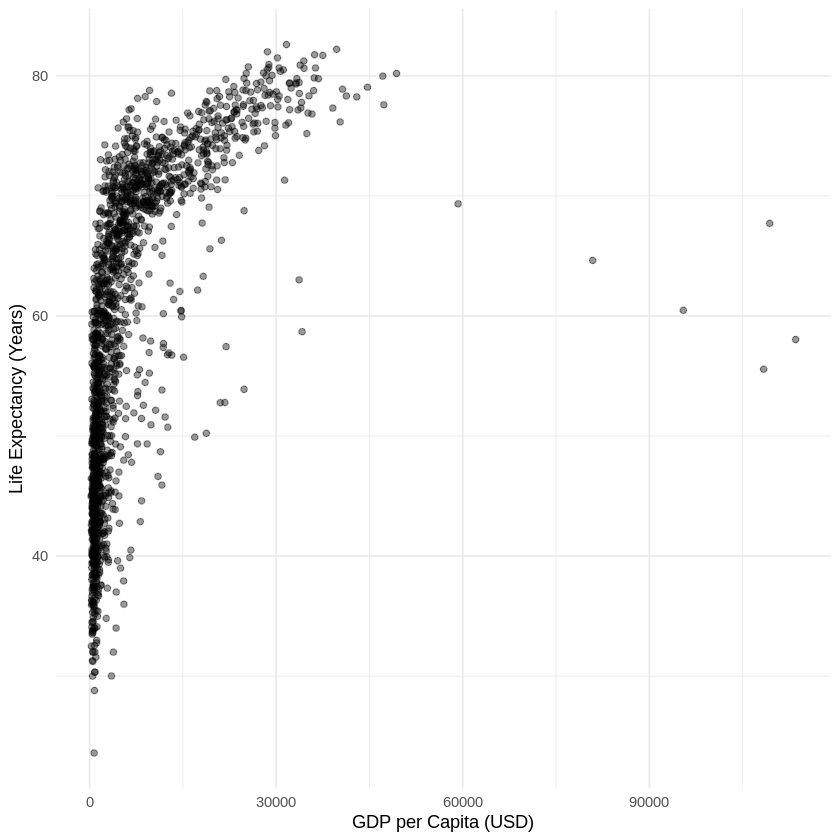

In [9]:
ggplot(df, aes(x = gdpPercap, y = lifeExp)) +
  geom_point(alpha = 0.4, size = 1.5) +
  labs(x = "GDP per Capita (USD)",
       y = "Life Expectancy (Years)") +
  theme_minimal()

> How can we improve this graph?

### Plot V2: Focus on year 2007 and color by continent

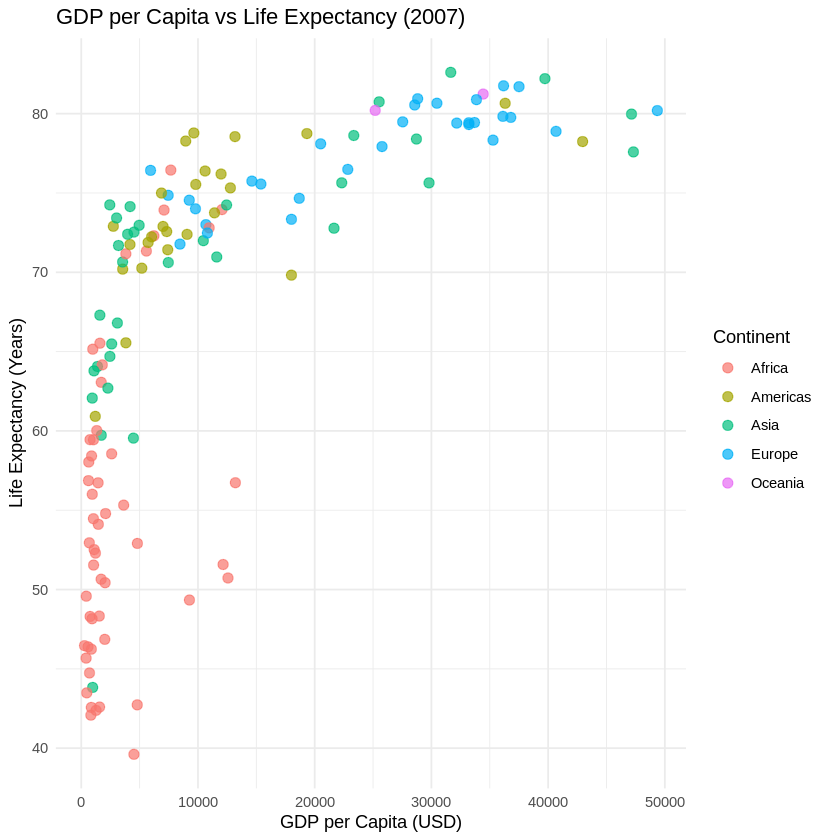

In [10]:
ggplot(df2007, aes(x = gdpPercap, y = lifeExp, color = continent)) +
  geom_point(alpha = 0.7, size = 2.5) +
  labs(x = "GDP per Capita (USD)",
       y = "Life Expectancy (Years)",
       title = "GDP per Capita vs Life Expectancy (2007)",
       color = "Continent") +
  theme_minimal()

### Plot V3: Log scale is useful when data is skewed

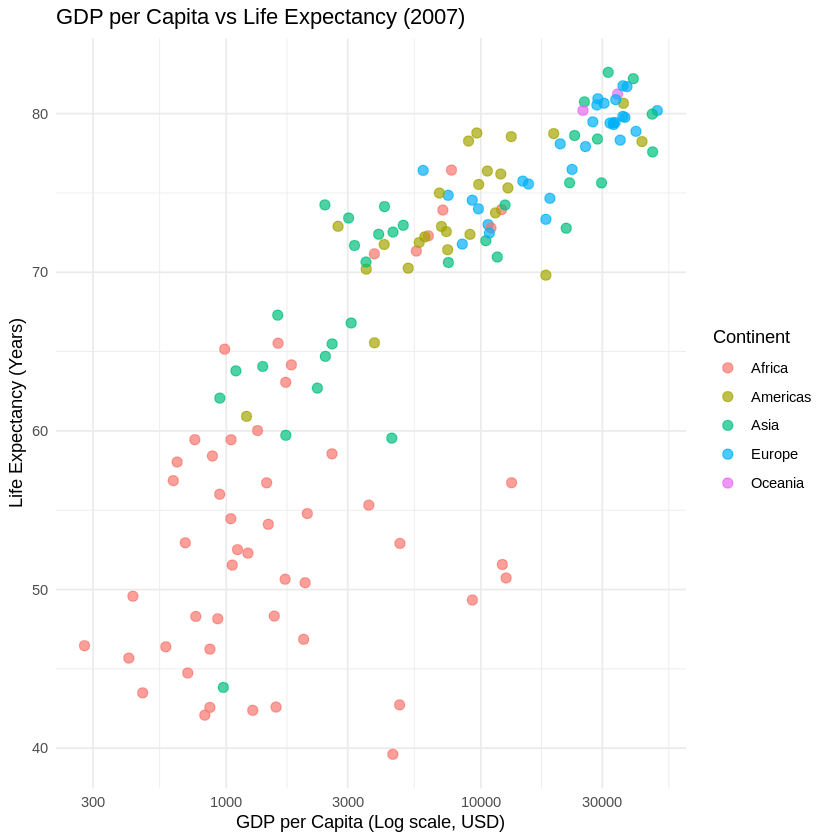

In [11]:
ggplot(df2007, aes(x = gdpPercap, y = lifeExp, color = continent)) +
  geom_point(alpha = 0.7, size = 2.5) +
  scale_x_log10() +
  labs(x = "GDP per Capita (Log scale, USD)",
       y = "Life Expectancy (Years)",
       title = "GDP per Capita vs Life Expectancy (2007)",
       color = "Continent") +
  theme_minimal()

### Plot V4: Show multiple years

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


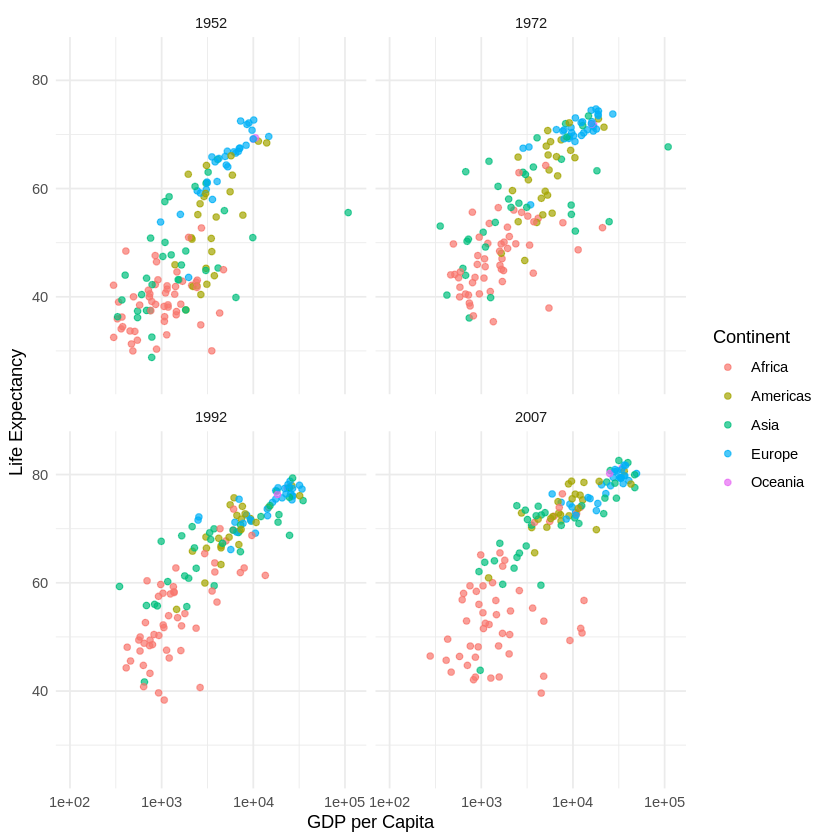

In [12]:
df %>%
  filter(year %in% c(1952, 1972, 1992, 2007)) %>%
  ggplot(aes(x = gdpPercap, y = lifeExp, color = continent)) +
  geom_point(alpha = 0.7, size = 1.5) +
  scale_x_log10(limits = c(100, 120000)) +
  ylim(25, 85) +
  facet_wrap(~year) +
  labs(x = "GDP per Capita",
       y = "Life Expectancy",
       color = "Continent") +
  theme_minimal()

## Transform data

In [13]:
# Create log-transformed variables
df <- df %>%
  mutate(ln_le = log(lifeExp),
         ln_gdppc = log(gdpPercap))

head(df, 5)

country,continent,year,lifeExp,pop,gdpPercap,ln_le,ln_gdppc
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,Asia,1952,28.801,8425333,779.4453,3.360410,6.658583
Afghanistan,Asia,1957,30.332,9240934,820.8530,3.412203,6.710344
Afghanistan,Asia,1962,31.997,10267083,853.1007,3.465642,6.748878
Afghanistan,Asia,1967,34.020,11537966,836.1971,3.526949,6.728864
Afghanistan,Asia,1972,36.088,13079460,739.9811,3.585960,6.606625


### Plot V5: Scatter plot in log units

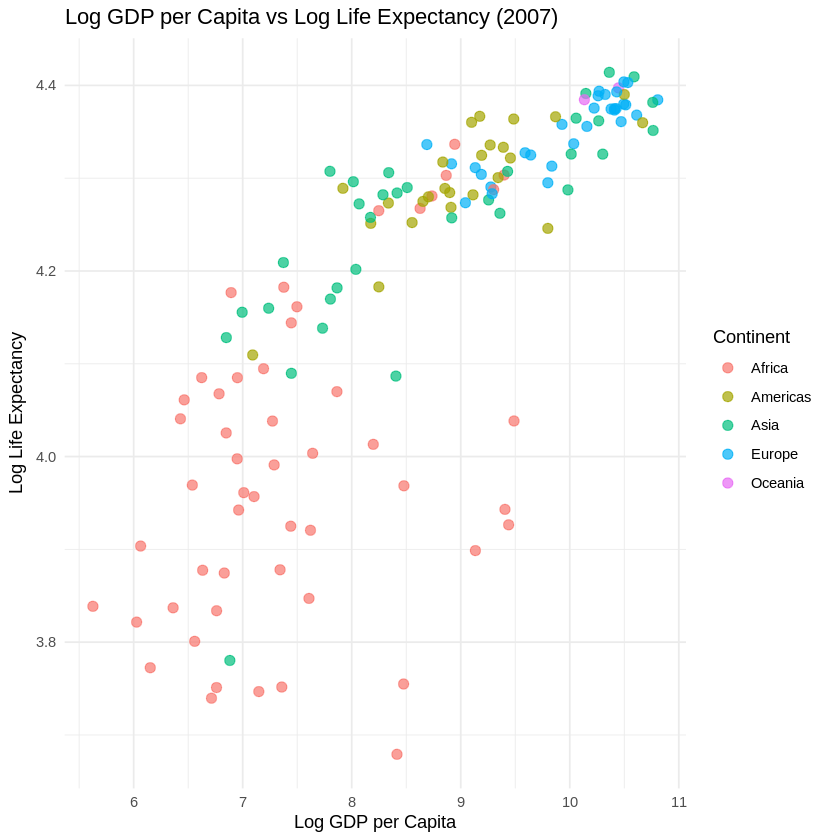

In [14]:
df2007 <- df %>% filter(year == 2007)

ggplot(df2007, aes(x = ln_gdppc, y = ln_le, color = continent)) +
  geom_point(alpha = 0.7, size = 2.5) +
  labs(x = "Log GDP per Capita",
       y = "Log Life Expectancy",
       title = "Log GDP per Capita vs Log Life Expectancy (2007)",
       color = "Continent") +
  theme_minimal()

## Data modeling

### Plot V6: Add regression line

In [15]:
# Fit a linear regression: ln_le ~ ln_gdppc
model <- lm(ln_le ~ ln_gdppc, data = df2007)
summary(model)


Call:
lm(formula = ln_le ~ ln_gdppc, data = df2007)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.48470 -0.04520  0.02116  0.08063  0.21326 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 3.209368   0.067059   47.86   <2e-16 ***
ln_gdppc    0.113429   0.007689   14.75   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1238 on 140 degrees of freedom
Multiple R-squared:  0.6085,	Adjusted R-squared:  0.6057 
F-statistic: 217.6 on 1 and 140 DF,  p-value: < 2.2e-16


`geom_smooth()` using formula = 'y ~ x'


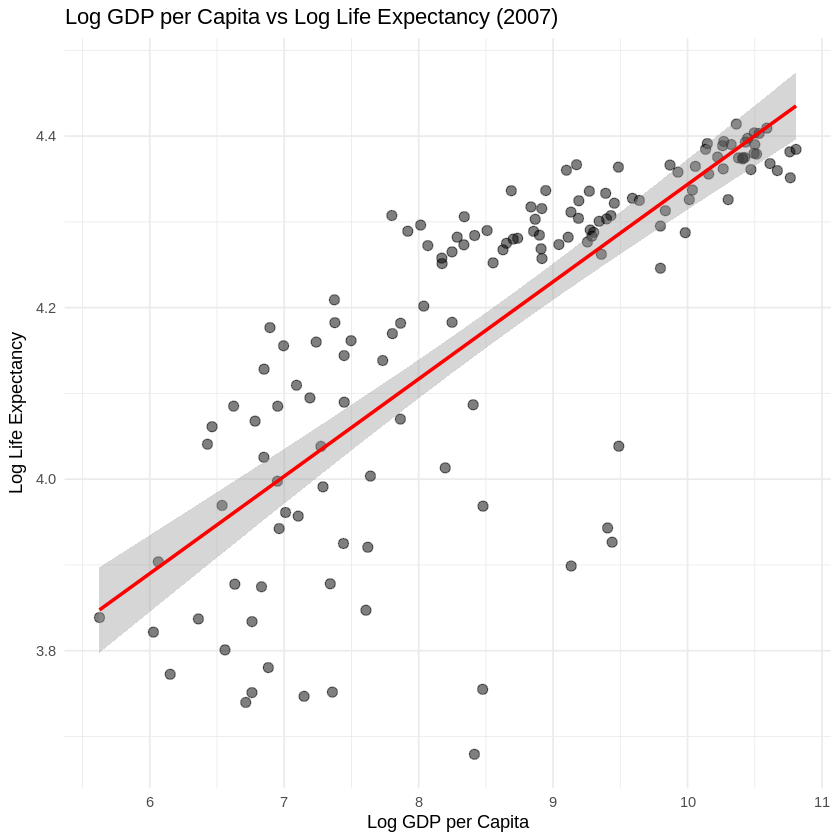

In [16]:
# Scatter plot with regression line
ggplot(df2007, aes(x = ln_gdppc, y = ln_le)) +
  geom_point(alpha = 0.5, size = 2.5) +
  geom_smooth(method = "lm", color = "red", se = TRUE) +
  labs(x = "Log GDP per Capita",
       y = "Log Life Expectancy",
       title = "Log GDP per Capita vs Log Life Expectancy (2007)") +
  theme_minimal()

### Regression results

In [17]:
# Coefficients table
tidy(model, conf.int = TRUE)

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.2093676,0.067059231,47.85870,1.179308e-88,3.07678787,3.3419473
ln_gdppc,0.1134293,0.007689312,14.75155,2.657415e-30,0.09822708,0.1286314


In [18]:
# Model fit statistics (R-squared, etc.)
glance(model)

r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.6085101,0.6057137,0.1238082,217.6082,2.657415e-30,1,96.15891,-186.3178,-177.4503,2.145986,140,142


In [19]:
# Confidence intervals for coefficients
confint(model)

,2.5 %,97.5 %
(Intercept),3.07678787,3.3419473
ln_gdppc,0.09822708,0.1286314


### Interpretation

- The coefficient of `ln_gdppc` tells us the **elasticity** of life expectancy with respect to GDP per capita.
- The p-value tests whether this relationship is statistically significant.
- The R² tells us how much of the variation in life expectancy is explained by GDP per capita.
- The confidence interval gives us a range of plausible values for the true coefficient.

### Plot V7: Regression lines by continent

`geom_smooth()` using formula = 'y ~ x'


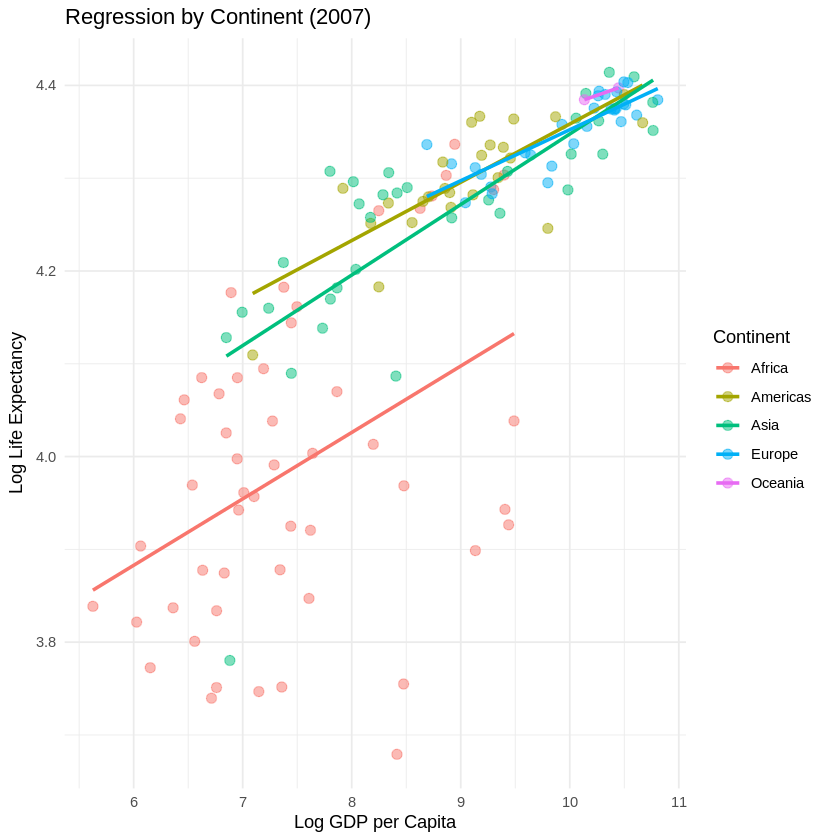

In [20]:
ggplot(df2007, aes(x = ln_gdppc, y = ln_le, color = continent)) +
  geom_point(alpha = 0.5, size = 2.5) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(x = "Log GDP per Capita",
       y = "Log Life Expectancy",
       title = "Regression by Continent (2007)",
       color = "Continent") +
  theme_minimal()

## Discussion questions

1. Based on your data exploration, what is the "big picture" story about the relationship between income and health?

2. How is the relationship between GDP per capita and life expectancy changing over time and across continents?

3. What limitations can you find in this exploratory analysis? How could you address those limitations?